In [1]:
%autosave 60

Autosaving every 60 seconds


# EDA: advance level
- очень рекомендую к просмотру: https://habr.com/ru/articles/468295/
- еще больше интересных примеров тут: https://github.com/MaximShalankin/maxim_ml/tree/main

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# pip install mplcyberpunk

In [4]:
# import matplotlib.pyplot as plt
# import mplcyberpunk

# plt.style.use("cyberpunk")

# plt.plot([1, 3, 9, 5, 2, 1, 1], marker='o')
# plt.plot([4, 5, 5, 7, 9, 8, 6], marker='o')

# mplcyberpunk.add_glow_effects()

# plt.show()

In [5]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

## пример визуализации 1

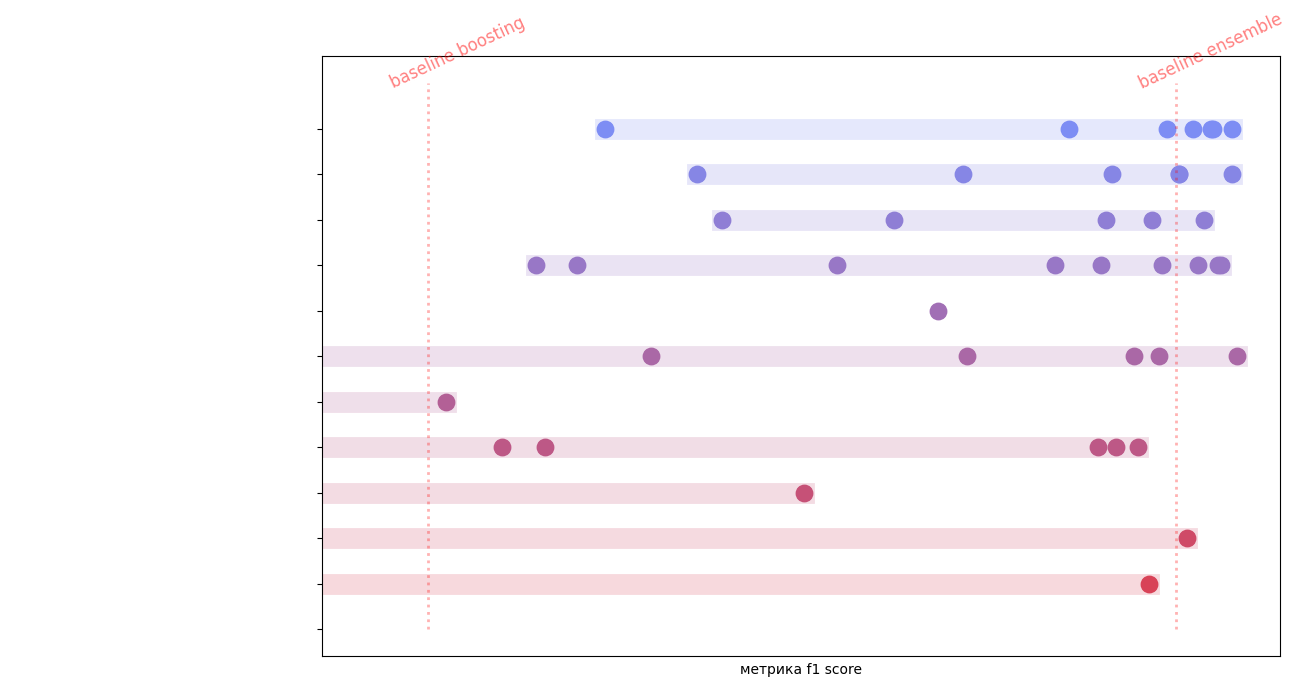

In [6]:
# Определение цветов и их позиций в градиенте
colors = ['#EA3338', '#7D8DF4']  # белый -> красный
positions = [0, 1]  # начало и конец

# Создание градиента
cmap = LinearSegmentedColormap.from_list("CustomRedWhite", list(zip(positions, colors)))

res = {'ансамблирование одного вида бустинга': [64906, 64604, 64646, 65232, 65288, 65291, 65171, 65268, 65125], 'ансамблирование разных бустингов': [65281, 64674, 65263, 65302, 65283, 65237, 65139], 'ансамблирование моделей разного типа': [62165, 64720, 65204, 65307, 65229, 65036], 'MLPClassifier fit predict': [65007], 'RandomForestClassifier fit predict': [62498, 61294, 60281, 62514], 'LGBMClassifier fit predict': [62699, 64873], 'LGBMClassifier fit predict_proba': [65257, 61093], 'CatBoostClassifier fit predict': [64613, 64301, 65168, 64570, 63714, 65186, 65208, 63073, 62535, 60968, 63429, 64152], 'CatBoostClassifier fit predict_proba': [65222, 64791, 64963, 65176, 65274], 'lightautoml': [65032, 65249, 64766, 65182, 65302, 65249], 'XGBClassifier fit predict': [61013, 65219, 60930], 'AdaBoostClassifier fit predict': [63964, 64514]}
res = [(k, np.array(v) / 100000) for k, v in res.items()]
res = sorted(res, key=lambda x: x[1].mean(), reverse=True)

plt.figure(figsize=(13, 7))
min_v = 999
max_v = 0

colors = []
for idx, (k, v) in enumerate(res[::-1]):
    
    v = sorted(v)
    plt.scatter(v, [idx] * len(v), color=cmap((idx+1) / len(res)), s=140)
    plt.plot(v, [idx] * len(v), color=cmap((idx+1) / len(res)), alpha=0.2, linewidth=15)

    min_v = min(min_v, min(v))
    max_v = max(max_v, max(v))
    colors.append(cmap((idx+1) / len(res)))
    
plt.yticks(range(len(res)), [i[0] for i in res][::-1], color='white')


# plt.xticks(np.arange(min_v, max_v, 0.005), label=np.arange(min_v, max_v, 0.001), color='black', rotation=35)
# plt.xticks(np.arange(0.643, max_v, 0.005), label=np.arange(min_v, max_v, 0.001), color='black', rotation=35)
# plt.grid(axis='y')
plt.grid(False)

plt.vlines(0.64496, 0, len(res), color='red', linewidth=2, linestyle=':', alpha=0.3)
plt.text(0.64456, 11.9, 'baseline boosting', rotation=25, color='red', alpha=0.5, fontsize=12)

plt.vlines(0.65246, 0, len(res), color='red', linewidth=2, linestyle=':', alpha=0.3)
plt.text(0.65206, 11.9, 'baseline ensemble', rotation=25, color='red', alpha=0.5, fontsize=12)

plt.xticks([])
plt.xlim(left=0.6439, right=0.6535)

plt.xlabel('метрика f1 score')
# plt.title('результат соревнования ML MTS TETA')
plt.tight_layout()
# plt.savefig('mts_comp.png', dpi=800)

plt.show()

## пример визуализации 2

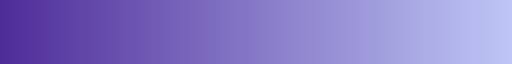

In [7]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'my_cmap', [
        "#4F2D99",  "#BFC6F6",
    ]
)

custom_cmap

In [8]:
# Определяем целевую функцию
def f(x, y):
    return x**2 + y**2

# Градиент функции
def gradient(x, y):
    return np.array([2*x, 2*y])

# Реализация градиентного спуска
def gradient_descent(starting_point, learning_rate, num_iterations):
    point = np.array(starting_point, dtype=np.float64)
    path = [point.copy()]
    
    for _ in range(num_iterations):
        grad = gradient(point[0], point[1])
        point -= learning_rate * grad
        path.append(point.copy())
    
    return np.array(path)

In [9]:
# Параметры градиентного спуска
starting_point = [3, 3]
learning_rate = 0.1
num_iterations = 5

# Получаем путь градиентного спуска
path = gradient_descent(starting_point, learning_rate, num_iterations)

# Создаем сетку для изолиний
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

In [10]:
path = np.array(
    [
        [3.     , 3.5     ],
        [3.4    , 1.4    ],
        [1.92   , 1.92   ],
        [1.36  , 1.  ],
        [0., 0.]
    ]
)

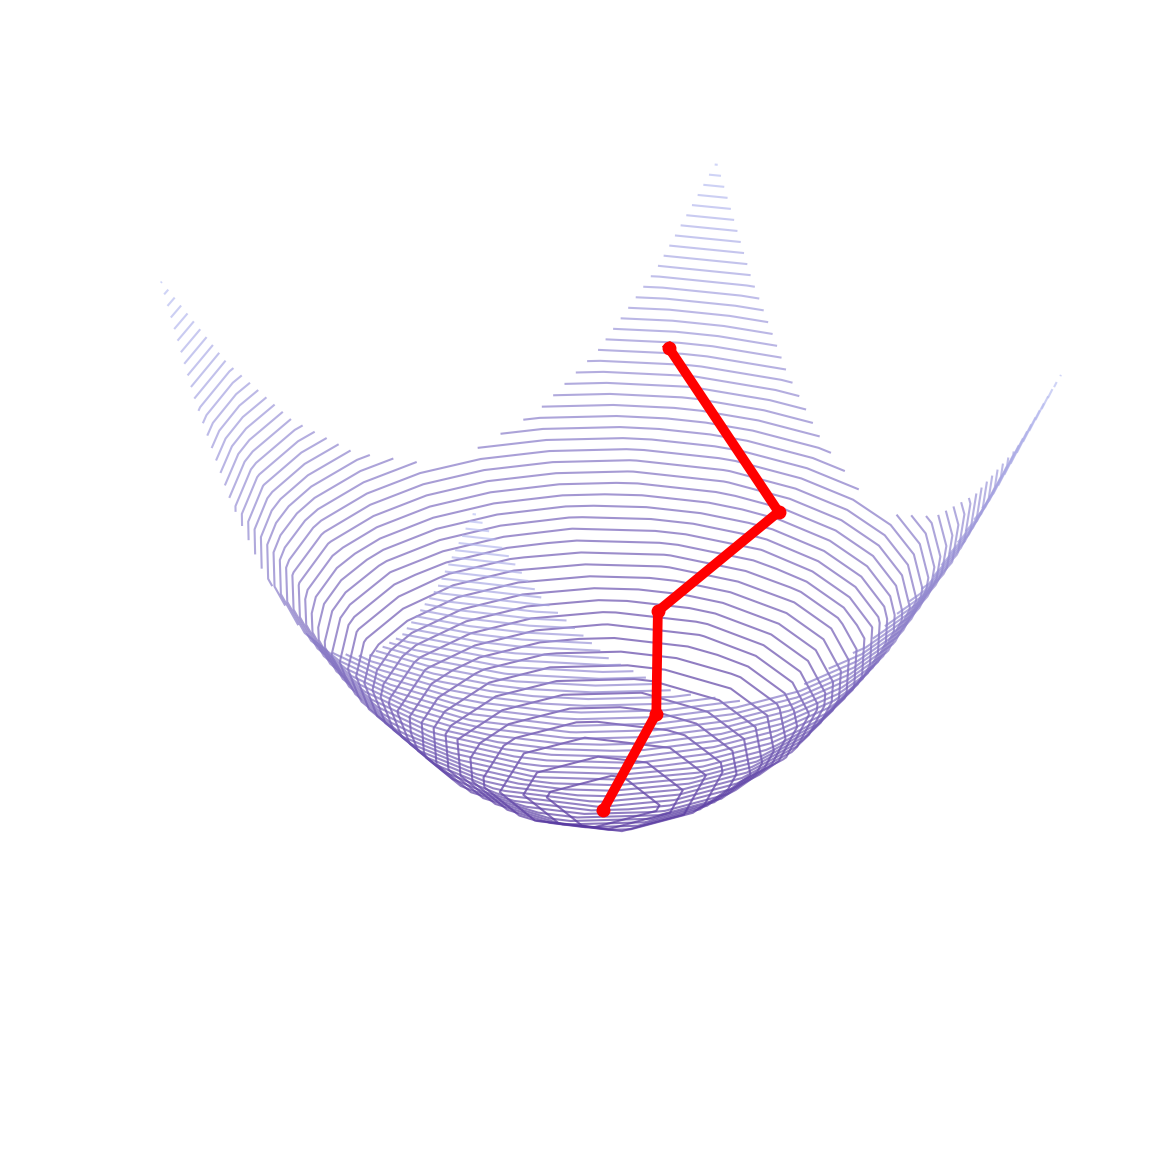

In [11]:
# Визуализация
# plt.xkcd()
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# Изолинии
ax.contour3D(X, Y, Z, levels=60, cmap=custom_cmap, alpha=0.7, zorder=0, linewidth=9)

# Путь градиентного спуска
ax.plot(path[:, 0], path[:, 1], f(path[:, 0], path[:, 1]), color='r', 
        marker='o', markersize=9, 
        zorder=12, linewidth=7)

# Установка угла визуализации
ax.view_init(elev=25, azim=240)

plt.axis('off')
plt.show()
# plt.savefig(
#     '../imgs_habr/gradient_d.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, transparent=True
# )

## пример визуализации 3

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# plt.xkcd()
# plt.rcParams["figure.facecolor"] = "#BFC6F6"
# plt.rcParams["axes.facecolor"] = "#BFC6F6"
# plt.rcParams['savefig.facecolor'] = "#BFC6F6"

In [14]:
def J(theta):
    return (theta**2 - 1.5)**2 + 0.5 * theta

In [15]:
# Параметры
theta_vals = np.linspace(-2., 2, 400)
learning_rates = [
    [0.1, 0.1], [0.9, 0.1]
]
n_iters = 6
colors = ['red', 'black']
labels = ['Learning Rate небольшой', 'Learning Rate большой']
initial_theta = 1.

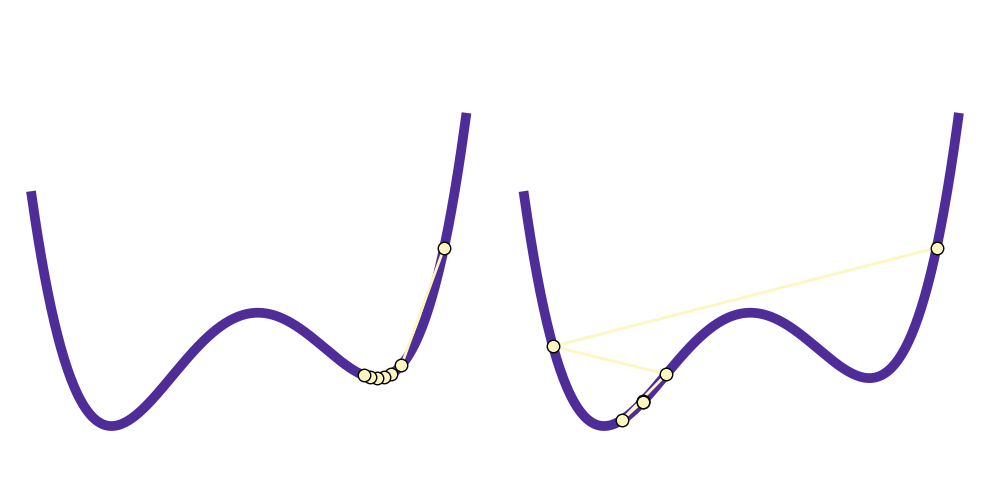

In [16]:
# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, lr in enumerate(learning_rates):
    initial_theta = 1.8
    theta = initial_theta
    trajectory = [theta]
    
    for idx in range(n_iters):
        theta = theta - (np.sign((2 * theta * (theta**2 - 1) + 0.5)) * np.linspace(*lr, n_iters)[idx] * J(theta))
        trajectory.append(theta)

    axes[i].plot(theta_vals, J(theta_vals), 'b-', color="#4F2D99", linewidth=7)
    axes[i].plot(
        trajectory, J(np.array(trajectory)), 
        'ro-', 
        linewidth=2, 
        color='#FDF6BF',
        marker='o', markersize=9,
        markeredgecolor='black', # цвет обводки маркеров
    )
    
    axes[i].grid(False)
    axes[i].axis('off')
    axes[i].set_ylim(-2, 10)

plt.tight_layout()

plt.show()

# plt.savefig(
#     '../imgs_habr/learning_2.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
#     transparent=True
# )

## пример визуализации 4

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
import matplotlib.patheffects as path_effects

In [18]:
# plt.rcParams

In [19]:
# plt.rcParams["figure.facecolor"] = "#BFC6F6"
# plt.rcParams["axes.facecolor"] = "#BFC6F6"
# plt.rcParams['savefig.facecolor'] = "#BFC6F6"

In [20]:
# Генерация случайных данных
np.random.seed(3)

X = 2 * np.random.rand(12, 1)
y = 4 + 3 * X + np.random.randn(12, 1)

vv = [3, 3, 10]

In [21]:
# Функция для отображения графиков
def plot_iteration(ax, model, X, y, title):
    ax.plot(
        X, y,
        'r.', 
        linewidth=2, 
        color='#FDF6BF',
        marker='o', 
        markersize=14,
        markeredgecolor='black',
        zorder=12
    )
    
    # Предсказанные значения
    X_new = np.array([[X.min()], [X.max()]])
    y_pred = model.predict(X_new)
    ax.plot(X_new, y_pred, 'b-', color="#4F2D99", linewidth=7)
    
    # Расчет и отображение перпендикуляров и ошибок
    total_error = 0
    for i in range(len(X)):
        y_proj = model.predict(X[i].reshape(1, -1))
        error = abs(y[i] - y_proj)
        total_error += error
        
        # Отображение перпендикуляров
        ax.plot([X[i], X[i]], [y[i], y_proj], 'k--', lw=2, alpha=0.5, color="#4F2D99")
        
        # Отображение ошибок для четных точек
        if i % 2 == 0:
            txt = ax.text(X[i]-0.1, (y[i]), f'{error[0]:.2f}', fontsize=12, color='#4F2D99', zorder=12, fontweight='bold')
            txt.set_path_effects([path_effects.Stroke(linewidth=1, foreground='white'),
                                  path_effects.Normal()])

    print(f'{title}\nобщая ошибка: {total_error[0]:.1f}')
    
    ax.grid(False)
    ax.axis('off')
    ax.set_ylim(1, 13)
    
    ax.set_yticks([])
    ax.set_xticks([])

итерация 1
общая ошибка: 39.1
итерация 2
общая ошибка: 20.3
итерация 3
общая ошибка: 10.3


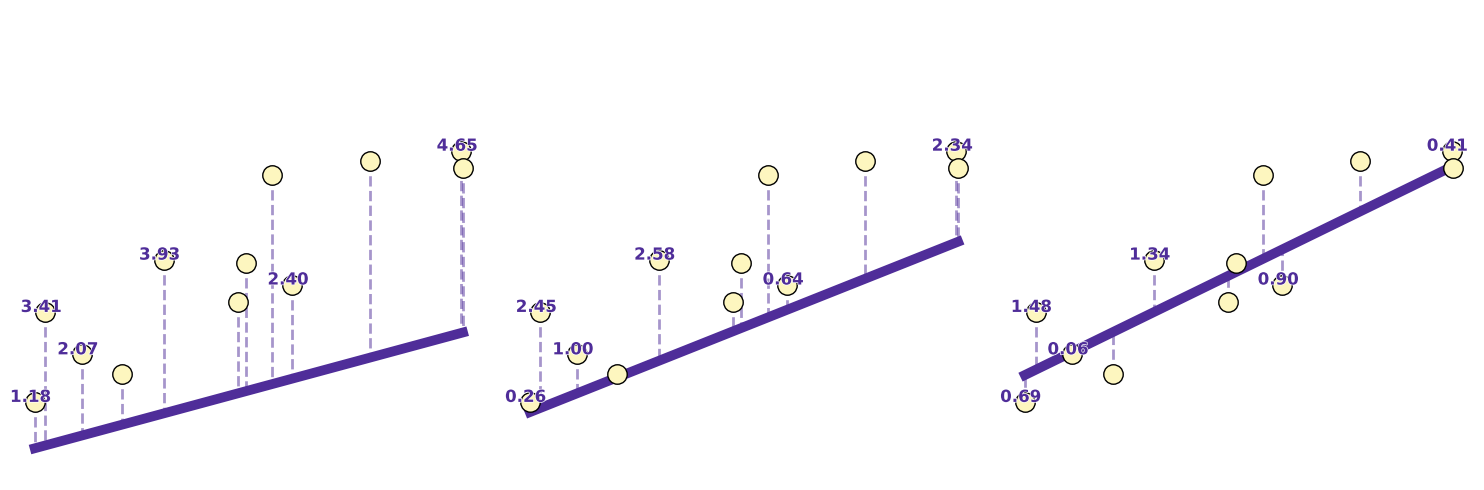

In [22]:
# Создаем 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Инициализация модели линейной регрессии c итеративным обучением
model = SGDRegressor(max_iter=1, tol=None, eta0=0.01, learning_rate='constant', penalty='l2', alpha=0.1, random_state=0)

# Обучение и визуализация первых трех итераций
for i, ax in enumerate(axes):
    for _ in range(vv[i]):
        model.partial_fit(X, y.ravel())
    plot_iteration(ax, model, X, y, f'итерация {i + 1}')

# Отображение графиков
plt.tight_layout()
plt.show()

# plt.savefig(
#     '../imgs_habr/esr_error_1.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
# #     transparent=True
# )

# Проводим EDA

In [136]:
from matplotlib import colormaps
len(list(colormaps))

170

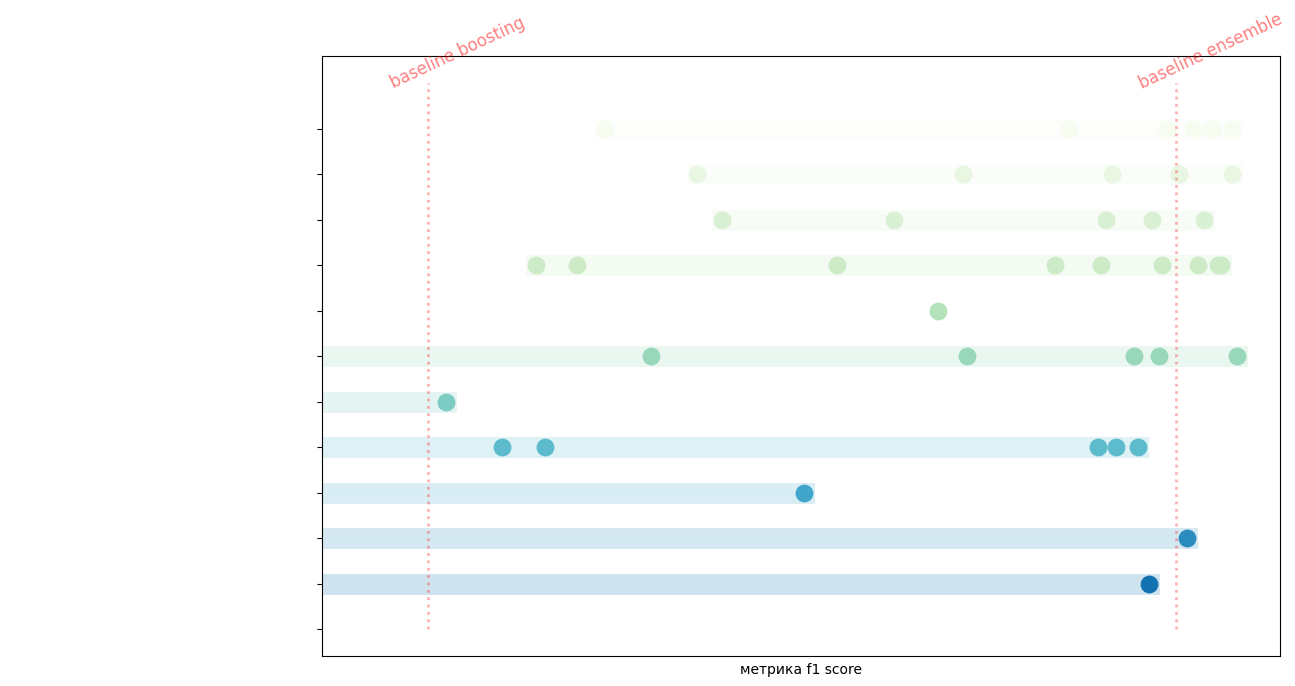

In [27]:
# Определение цветов и их позиций в градиенте
colors = ['#EA3338', '#7D8DF4']  # белый -> красный
positions = [0, 1]  # начало и конец

# Создание градиента
cmap = mpl.colormaps[list(colormaps)[100]] # LinearSegmentedColormap.from_list("CustomRedWhite", list(zip(positions, colors)))

res = {'ансамблирование одного вида бустинга': [64906, 64604, 64646, 65232, 65288, 65291, 65171, 65268, 65125], 'ансамблирование разных бустингов': [65281, 64674, 65263, 65302, 65283, 65237, 65139], 'ансамблирование моделей разного типа': [62165, 64720, 65204, 65307, 65229, 65036], 'MLPClassifier fit predict': [65007], 'RandomForestClassifier fit predict': [62498, 61294, 60281, 62514], 'LGBMClassifier fit predict': [62699, 64873], 'LGBMClassifier fit predict_proba': [65257, 61093], 'CatBoostClassifier fit predict': [64613, 64301, 65168, 64570, 63714, 65186, 65208, 63073, 62535, 60968, 63429, 64152], 'CatBoostClassifier fit predict_proba': [65222, 64791, 64963, 65176, 65274], 'lightautoml': [65032, 65249, 64766, 65182, 65302, 65249], 'XGBClassifier fit predict': [61013, 65219, 60930], 'AdaBoostClassifier fit predict': [63964, 64514]}
res = [(k, np.array(v) / 100000) for k, v in res.items()]
res = sorted(res, key=lambda x: x[1].mean(), reverse=True)

plt.figure(figsize=(13, 7))
min_v = 999
max_v = 0

colors = []
for idx, (k, v) in enumerate(res[::-1]):
    
    v = sorted(v)
    plt.scatter(v, [idx] * len(v), color=cmap((idx+1) / len(res)), s=140)
    plt.plot(v, [idx] * len(v), color=cmap((idx+1) / len(res)), alpha=0.2, linewidth=15)

    min_v = min(min_v, min(v))
    max_v = max(max_v, max(v))
    colors.append(cmap((idx+1) / len(res)))
    
    

plt.yticks(range(len(res)), [i[0] for i in res][::-1], color='white')


# plt.xticks(np.arange(min_v, max_v, 0.005), label=np.arange(min_v, max_v, 0.001), color='black', rotation=35)
# plt.xticks(np.arange(0.643, max_v, 0.005), label=np.arange(min_v, max_v, 0.001), color='black', rotation=35)
# plt.grid(axis='y')
plt.grid(False)

plt.vlines(0.64496, 0, len(res), color='red', linewidth=2, linestyle=':', alpha=0.3)
plt.text(0.64456, 11.9, 'baseline boosting', rotation=25, color='red', alpha=0.5, fontsize=12)

plt.vlines(0.65246, 0, len(res), color='red', linewidth=2, linestyle=':', alpha=0.3)
plt.text(0.65206, 11.9, 'baseline ensemble', rotation=25, color='red', alpha=0.5, fontsize=12)

plt.xticks([])
plt.xlim(left=0.6439, right=0.6535)

plt.xlabel('метрика f1 score')
# plt.title('результат соревнования ML MTS TETA')
plt.tight_layout()
# plt.savefig('mts_comp.png', dpi=800)

plt.show()

In [44]:
import os
import pandas as pd
import numpy as np

In [33]:
df = pd.read_csv('/Users/mdshalanki/Downloads/StudentsPerformance.csv')

In [35]:
target = df['math score']
X = df.drop('math score', axis=1)

## EDA 

In [128]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [42]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

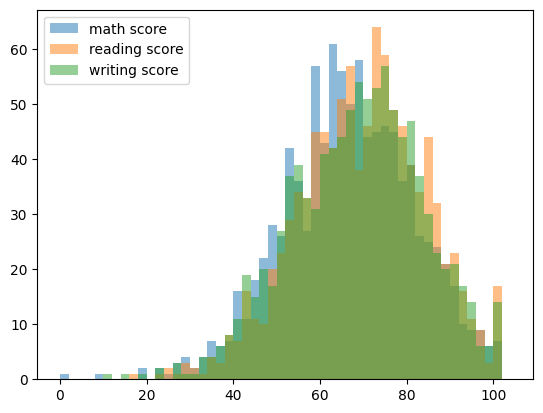

In [60]:
bins = np.arange(0, 105, 2)
plt.hist(list(df['math score'].values) * 1, bins=bins, alpha=0.5, label='math score')
plt.hist(list(df['reading score'].values) * 1, bins=bins, alpha=0.5, label='reading score')
plt.hist(df['writing score'], bins=bins, alpha=0.5, label='writing score')

# KDE PLOT
plt.legend()
plt.show()

In [65]:
x1 = np.array(list(df['math score'].values) * 10)
x2 = np.array(list(df['reading score'].values) * 5)
x3 = df['writing score'].values

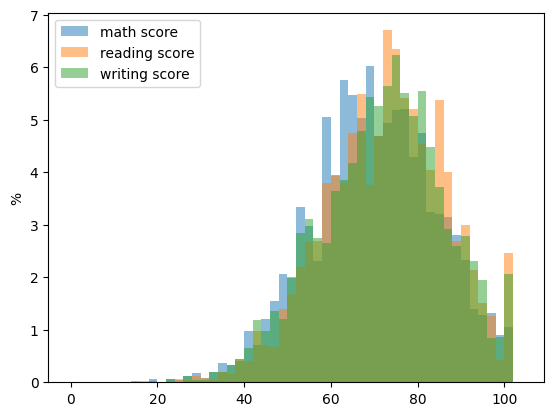

In [76]:
bins = np.arange(0, 105, 2)
plt.hist(x1, bins=bins, alpha=0.5, weights=100 * (x1 / sum(x1)),label='math score')
plt.hist(x2, bins=bins, alpha=0.5, weights=100 * (x2 / sum(x2)),label='reading score')
plt.hist(x3, bins=bins, alpha=0.5, weights=100 * (x3 / sum(x3)),label='writing score')

plt.ylabel('%')
plt.legend()
plt.show()

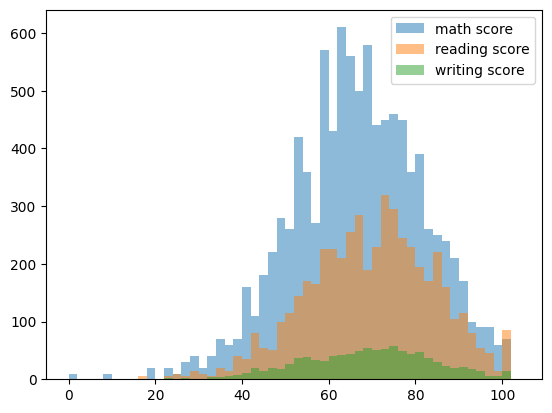

In [75]:
bins = np.arange(0, 105, 2)
plt.hist(x1, bins=bins, alpha=0.5, label='math score')
plt.hist(x2, bins=bins, alpha=0.5, label='reading score')
plt.hist(x3, bins=bins, alpha=0.5, label='writing score')
# plt.ylabel('%')
plt.legend()
plt.show()

In [ ]:
# проверить таргет 
# проверит корреляцию с таргетом
# проверить парные зависимости

In [79]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [82]:
df[['math score', 'reading score', 'writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [ ]:
# посмотреть корреляцию с кат. переменными

In [ ]:
order = [
    'some high school', 'high school', 'some college', 'associates degree', 'bachelors degree', 'masters degree', 
]

In [116]:
mean_result_1 = df.groupby('parental level of education')['math score'].mean()
mean_result_2 = df.groupby('parental level of education')['reading score'].mean()
mean_result_3 = df.groupby('parental level of education')['writing score'].mean()

In [120]:
from collections import defaultdict

In [123]:
res = defaultdict(list)
for key in mean_result_1.to_dict().keys():
    res[key].append(round(mean_result_1[key], 2))
    res[key].append(round(mean_result_2[key], 2))
    res[key].append(round(mean_result_3[key], 2))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [132]:
# Configuration 1
CONFIG = {
    "title": "Оценка на экзамен",
    "xlabel": "% компаний",
    "xlim": [-100, 300],
    "img_name": "img_1.png",
    "colormaps": {
        "green": ["#2D5F2E", "#8CB369"],
        "red": ["#C14953", "#6D1A1A"]
    },
    "bar_width": 0.65,
    "left_ticks": 1,
    "font": "Arial",
    "grid_color": "#EAEAEA",
    "text_colors": {
        "green": "#FFFFFF",
        "red": "#FFFFFF"
    },
    "ticks": ['прошли экзамен', 'пересдача', 'завалили'],
    "data": {
        "associate's degree": [67.88, 70.93, 69.9],
        "bachelor's degree": [69.39, 73.0, 73.38],
        'high school': [62.14, 64.7, 62.45],
        "master's degree": [69.75, 75.37, 75.68],
        'some college': [67.13, 69.46, 68.84],
        'some high school': [63.5, 66.94, 64.89],
    }
}

In [133]:
CONFIG['data'] = dict(
    sorted(CONFIG['data'].items(), key=lambda x: sum(x[1][: CONFIG['left_ticks']]), reverse=False))


def create_colormaps():
    """Create LinearSegmentedColormap objects from the CONFIG colormaps."""
    cmaps = {}
    for name, colors in CONFIG["colormaps"].items():
        cmaps[name] = mcolors.LinearSegmentedColormap.from_list(name, colors)
    return cmaps


def add_labels(ax, bars, values, color_type):
    """Add value labels to the bars with appropriate text color."""
    text_color = CONFIG["text_colors"][color_type]
    for bar, value in zip(bars, values):
        if value == 0:
            continue
        width = bar.get_width()
        x = bar.get_x() + width / 2
        y = bar.get_y() + bar.get_height() / 2
        ax.text(x, y, f"{int(value)}",
                ha='center', va='center',
                color=text_color, fontsize=14)


def add_style(ax):
    """Apply professional styling elements."""
    plt.rcParams['font.family'] = CONFIG["font"]
    ax.xaxis.grid(True, color=CONFIG["grid_color"], linestyle='--')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axvline(0, color='#404040', linewidth=0.8, alpha=0.8)


def plot_segments(ax, data, cmaps):
    """Plot the horizontal bar segments with correct colors."""
    categories = list(data.keys())
    params = [
        {'direction': 'left', 'cmap': cmaps['green'], 'color': 'green',
         'indices': range(CONFIG["left_ticks"]), 'edgecolor': '#404040'},
        {'direction': 'right', 'cmap': cmaps['red'], 'color': 'red',
         'indices': range(CONFIG["left_ticks"], len(CONFIG["ticks"])), 'edgecolor': '#404040'}
    ]

    for param in params:
        base = np.zeros(len(categories))
        for idx, data_idx in enumerate(param['indices']):
            values = np.array([v[data_idx] for v in data.values()])
            width = -values if param['direction'] == 'left' else values
            norm_idx = idx / (len(param['indices']) - 0.8)
            color = param['cmap'](norm_idx)
            bars = ax.barh(
                np.arange(len(categories)), width,
                left=base, height=CONFIG["bar_width"],
                color=color, edgecolor=param['edgecolor'],
                linewidth=0.5, alpha=0.95
            )
            add_labels(ax, bars, values, param['color'])
            base += width


def create_plot(data):
    """Create the final plot with correct legend colors."""
    plt.rcParams['font.size'] = 12
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.set_title(CONFIG["title"], fontsize=18, pad=20, color='#2D2D2D', weight='semibold', y=1.2, x=0.27)
    ax.set_yticks(np.arange(len(data)))
    ax.set_yticklabels(data.keys(), color='#404040', fontsize=11)
    ax.set_xlim(*CONFIG['xlim'])
    ax.set_xticks([])

    cmaps = create_colormaps()
    plot_segments(ax, data, cmaps)
    add_style(ax)

    # Generate correct legend colors
    tick_colors = []
    for i in range(len(CONFIG["ticks"])):
        if i < CONFIG["left_ticks"]:
            cmap = cmaps['green']
            pos = i / (CONFIG["left_ticks"] - 0.8)
        else:
            cmap = cmaps['red']
            idx = i - CONFIG["left_ticks"]
            pos = idx / ((len(CONFIG["ticks"]) - CONFIG["left_ticks"]) - 0.8)
        tick_colors.append(cmap(pos))

    # Create legend handles
    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in tick_colors]

    # Add legend
    legend = ax.legend(
        handles=legend_handles,
        labels=CONFIG["ticks"],
        ncol=2, frameon=False,
        loc=(0.13, 1.05), fontsize=12
    )
    for text in legend.get_texts():
        text.set_color('#606060')

    plt.subplots_adjust(top=0.88, bottom=0.15)
    plt.xlabel(CONFIG['xlabel'])
    plt.tight_layout()
    plt.savefig(CONFIG['img_name'], format='png', dpi=120)

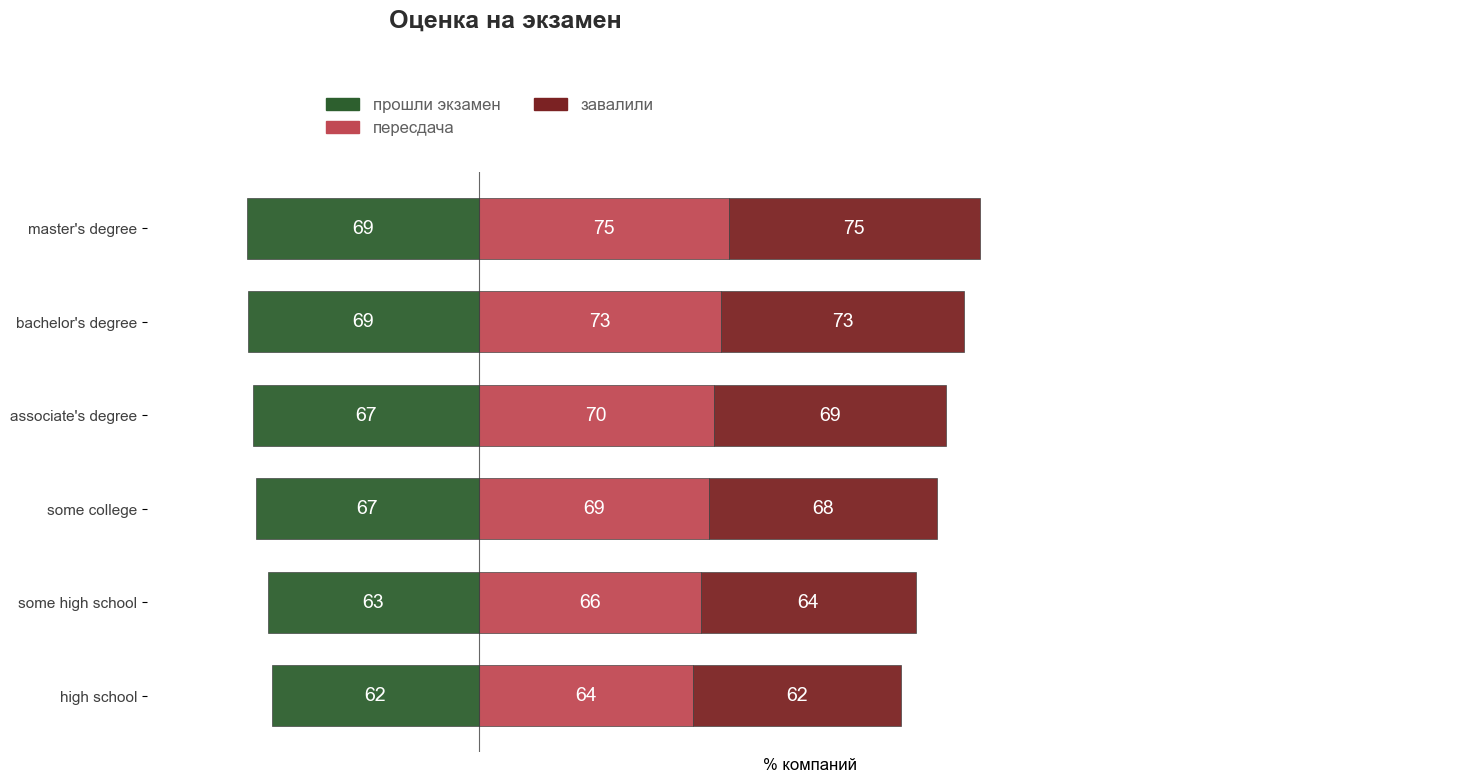

In [134]:
create_plot(CONFIG['data'])

In [135]:
# выбросы
# пропуски
# корреляция
# распределения величин
# гипотезы на таргете (целевая переменная)
#     распределения; уникальные значения; анализ данных в разрезе целевой переменной: cifar10 / cifar1000 (1 из 100) / (1 из 1000)
# *парные распределения величин
# *гипотеза влияния одной переменной на другую (линейная или нелинейная)